Data set Mountinig via google drive

In [ ]:
from google.colab import drive

# Mount Google Drive to access files stored in your Drive.
# This allows the Colab notebook to read and write files to your Google Drive.
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
Data_dir='/content/gdrive/MyDrive/datasets' # This variable stores the path to the main directory where your datasets are located in Google Drive.

In [ ]:
!ls '/content/gdrive/MyDrive/Datasets/palmtree/v1.01_4_1'

test  train  train.cache  val  val.cache


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.5 MB/s eta 0:00:00


Folder structure Identifying

In [ ]:
import os

folder_path = "/content/gdrive/MyDrive/Datasets/palmtree/v1.01_4_1/train"  # adjust if needed
files = os.listdir(folder_path)

for file in files:
    print(file)

.DS_Store
overripe
damaged
unripe
ripe


Preview classes with images

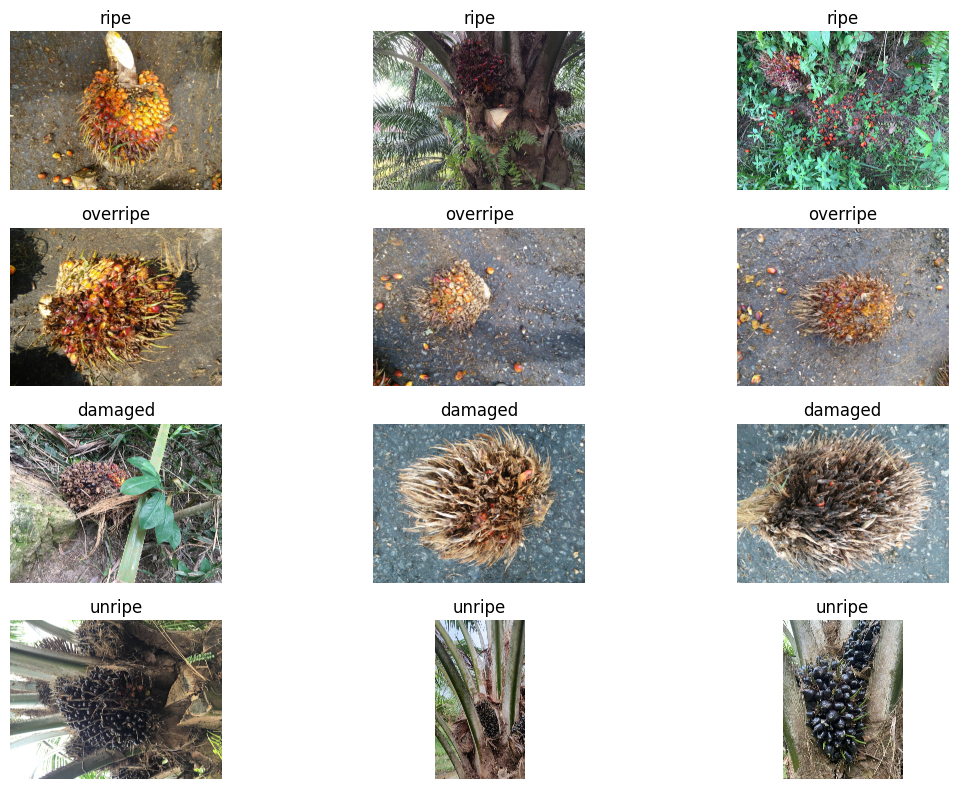

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import random

# Base train folder
train_base = "/content/gdrive/MyDrive/Datasets/palmtree/v1.01_4_1/train"

# List of classes
classes = ['ripe', 'overripe', 'damaged', 'unripe']

# Number of images to display per class
num_samples = 3

plt.figure(figsize=(12, 8))

for idx, cls in enumerate(classes):
    class_path = os.path.join(train_base, cls)

    # List all image files
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Pick random 3 images
    sample_images = random.sample(images, min(num_samples, len(images)))

    for jdx, img_name in enumerate(sample_images):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        # Plot in grid: 4 rows (classes) x 3 cols (samples)
        plt.subplot(len(classes), num_samples, idx*num_samples + jdx + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO("yolo11n-cls.pt")

results = model.train(data='/content/gdrive/MyDrive/Datasets/palmtree/v1.01_4_1', epochs=30, imgsz=64)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/gdrive/MyDrive/Datasets/palmtree/v1.01_4_1, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

Fine tune parameters analyzing

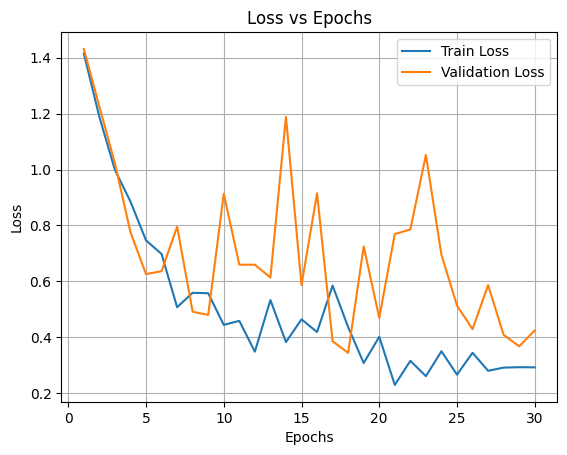

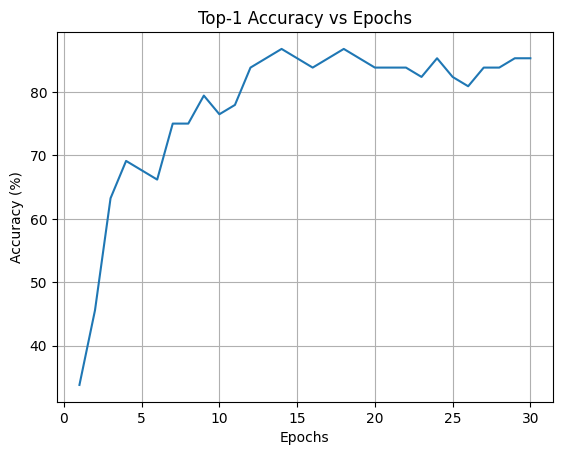

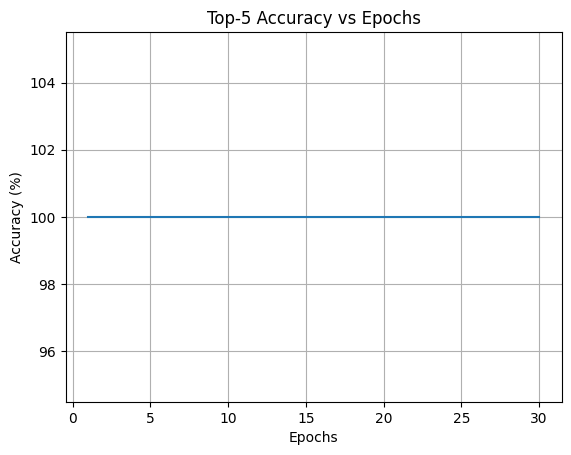

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to classification results
results_path = '/content/runs/classify/train/results.csv'

# Load results
results = pd.read_csv(results_path)

# -----------------------------
# 1️⃣ Loss vs Epochs
# -----------------------------
plt.figure()
plt.plot(results['epoch'], results['train/loss'], label='Train Loss')
plt.plot(results['epoch'], results['val/loss'], label='Validation Loss')
plt.grid()
plt.title('Loss vs Epochs')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend()


# -----------------------------
# 2️⃣ Top-1 Accuracy vs Epochs
# -----------------------------
plt.figure()
plt.plot(results['epoch'], results['metrics/accuracy_top1'] * 100)
plt.grid()
plt.title('Top-1 Accuracy vs Epochs')
plt.ylabel('Accuracy (%)')
plt.xlabel('Epochs')


# -----------------------------
# 3️⃣ Top-5 Accuracy vs Epochs
# -----------------------------
plt.figure()
plt.plot(results['epoch'], results['metrics/accuracy_top5'] * 100)
plt.grid()
plt.title('Top-5 Accuracy vs Epochs')
plt.ylabel('Accuracy (%)')
plt.xlabel('Epochs')

plt.show()

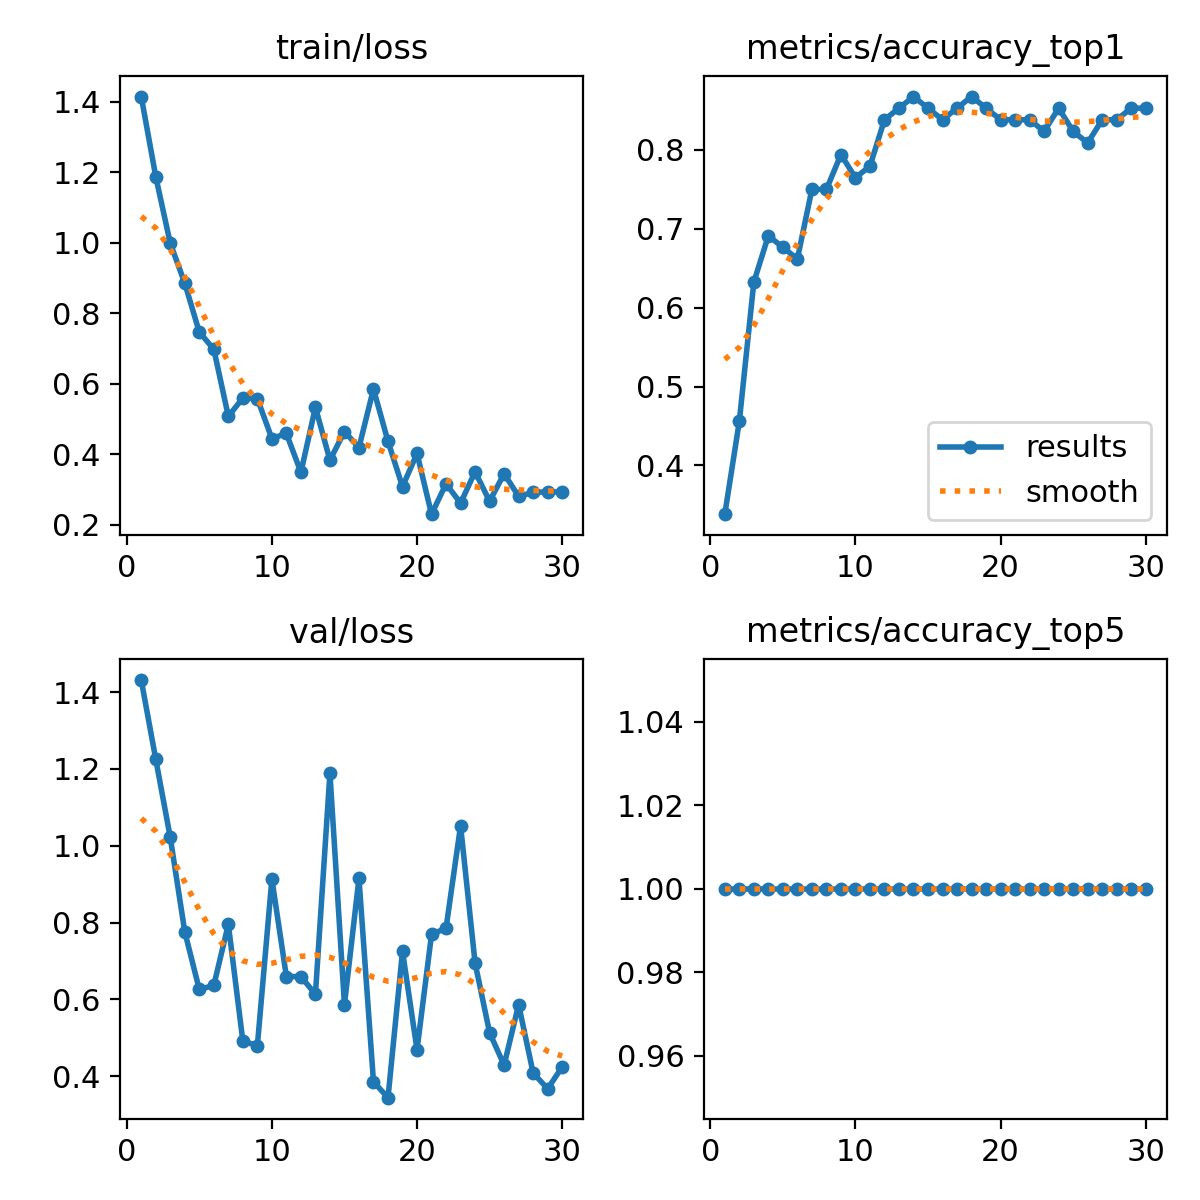

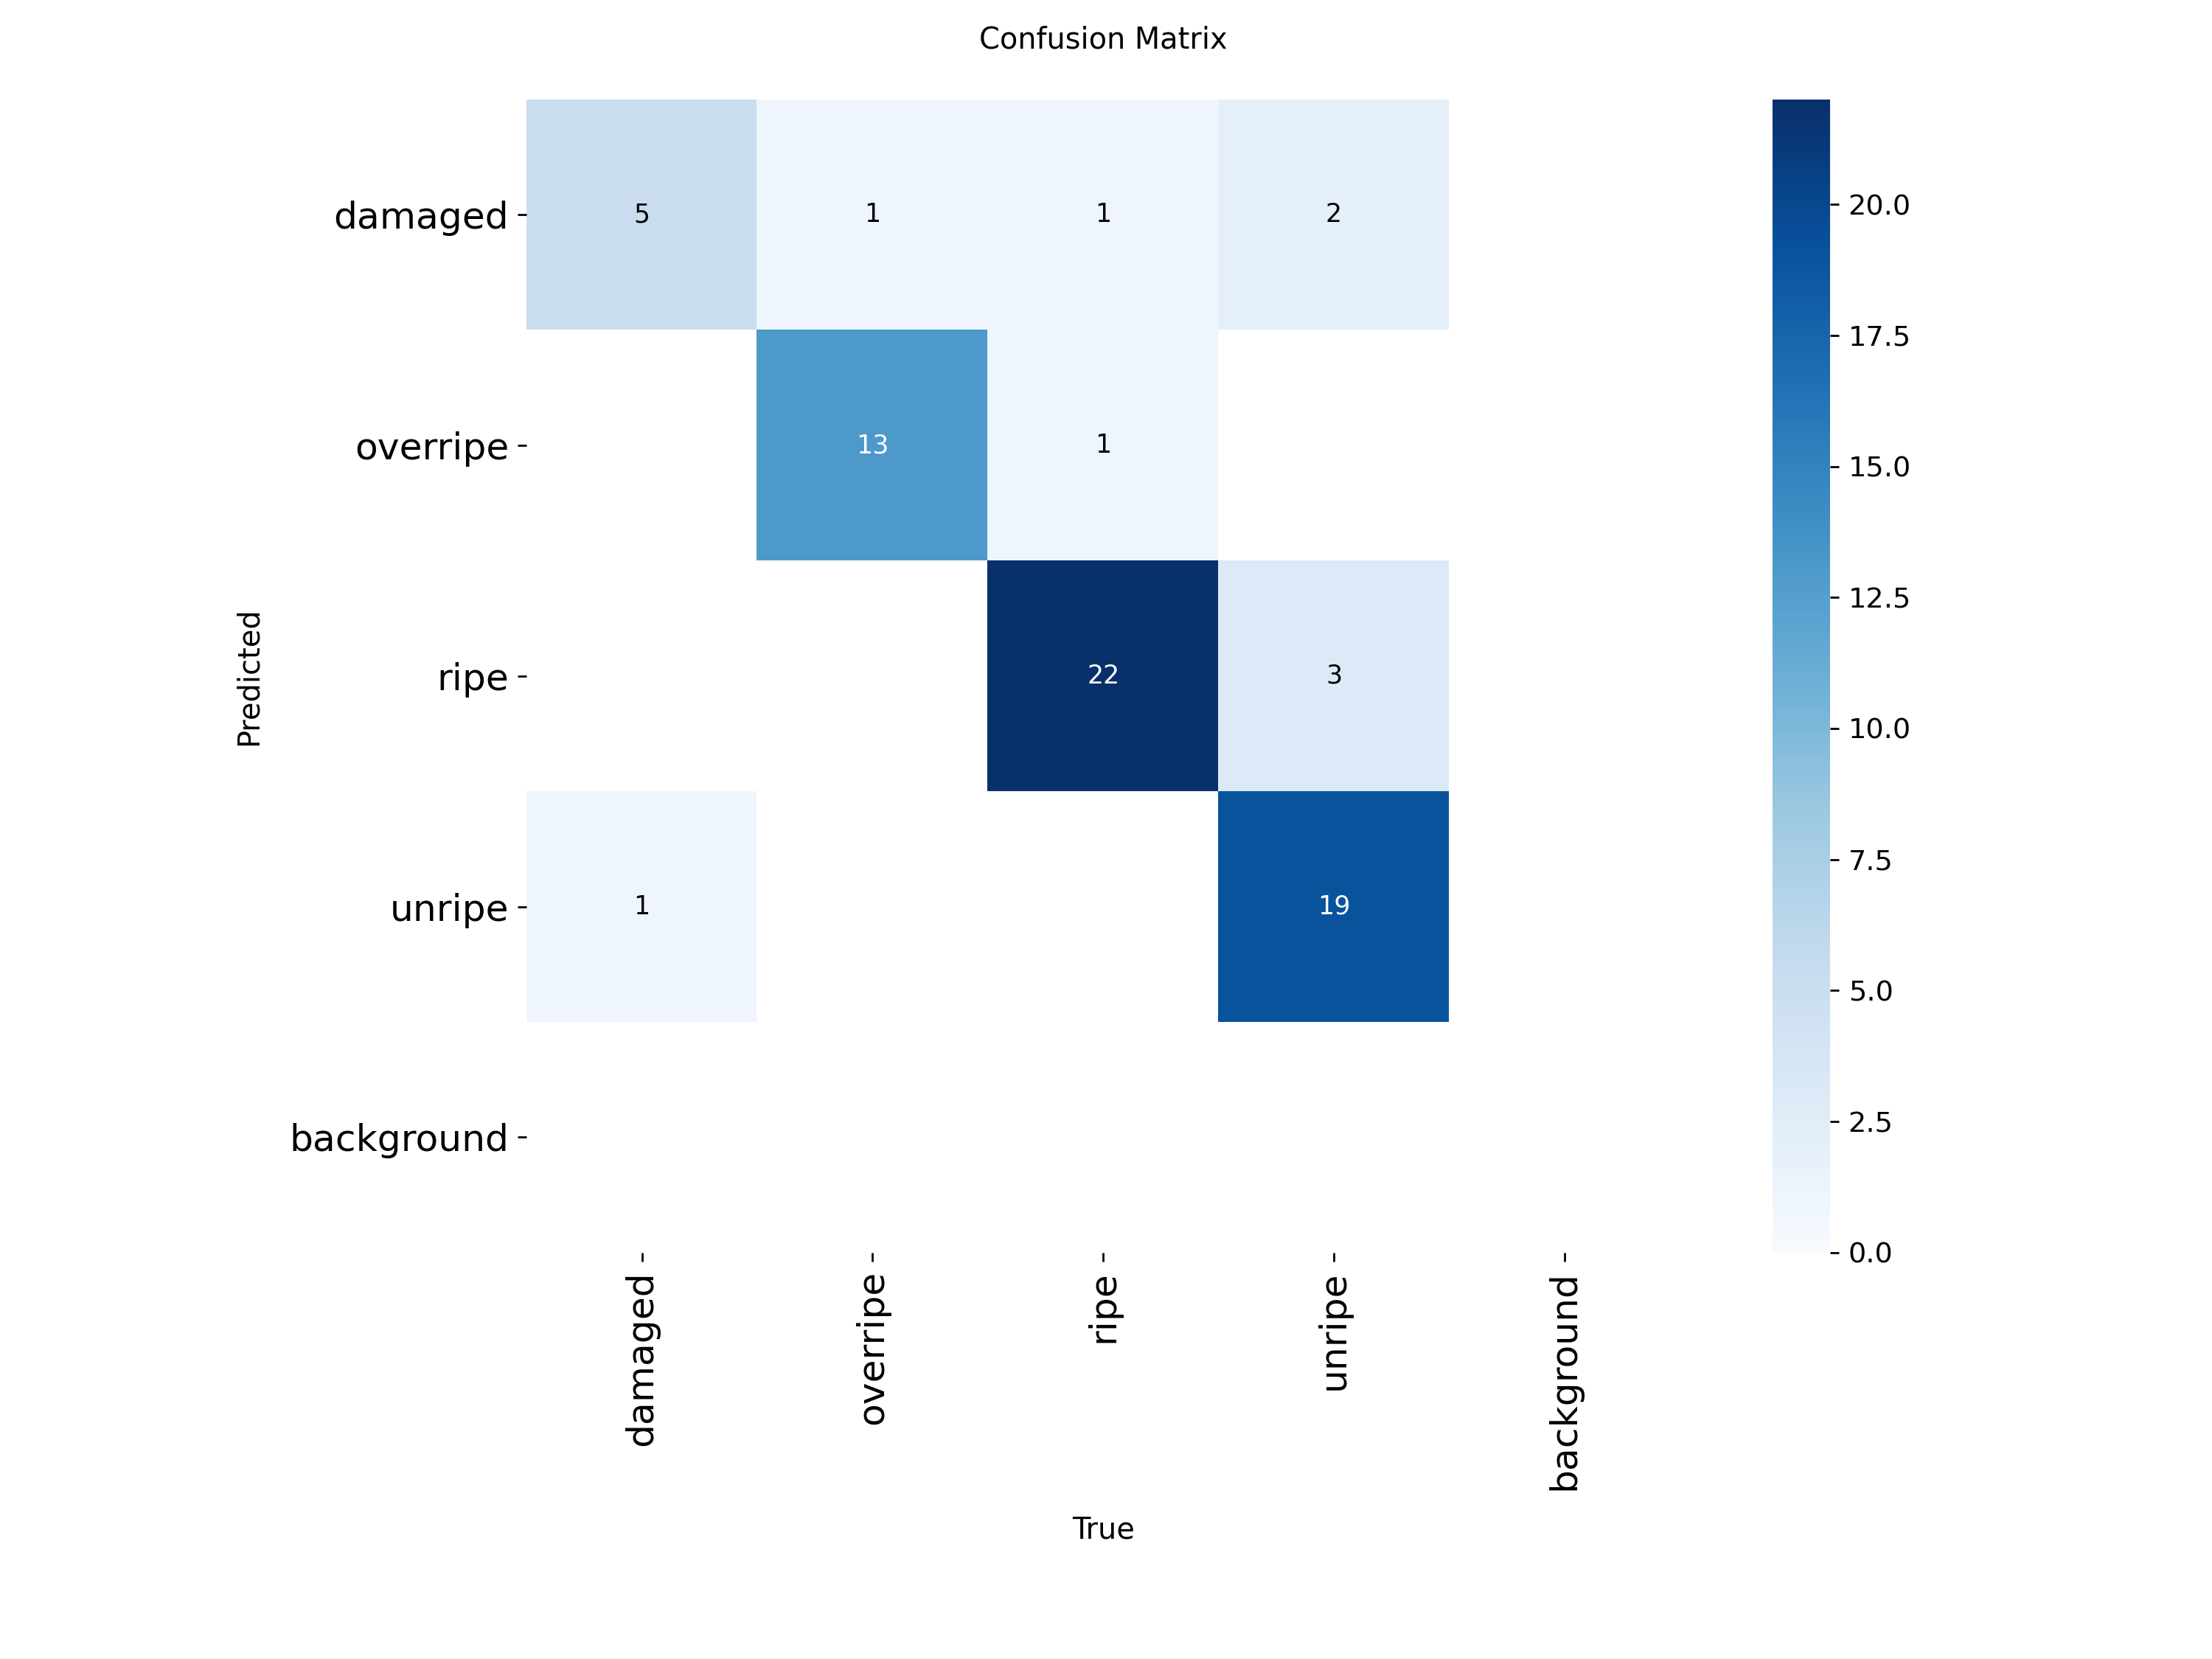

In [ ]:
from IPython.display import Image, display

display(Image(filename='/content/runs/classify/train/results.png'))
display(Image(filename='/content/runs/classify/train/confusion_matrix.png'))

Prediction Testing

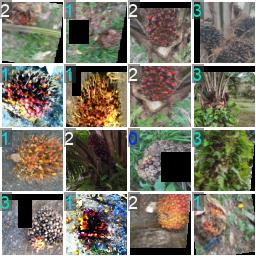

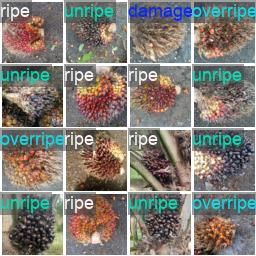

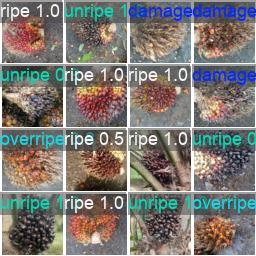

In [ ]:
display(Image(filename='/content/runs/classify/train/train_batch0.jpg'))
display(Image(filename='/content/runs/classify/train/val_batch0_labels.jpg'))
display(Image(filename='/content/runs/classify/train/val_batch0_pred.jpg'))

Inferencing for test data

In [ ]:

model = YOLO("/content/runs/classify/train/weights/best.pt")

In [ ]:
metrics = model.val(data="/content/gdrive/MyDrive/Datasets/palmtree/v1.01_4_1", split="test")

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n-cls summary (fused): 47 layers, 1,531,148 parameters, 0 gradients, 3.2 GFLOPs
train: /content/gdrive/MyDrive/Datasets/palmtree/v1.01_4_1/train... found 184 images in 4 classes ✅ 
val: /content/gdrive/MyDrive/Datasets/palmtree/v1.01_4_1/val... found 68 images in 4 classes ✅ 
WARNING ⚠️ test: /content/gdrive/MyDrive/Datasets/palmtree/v1.01_4_1/test... found 0 images in 0 classes (no images found)
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 334.1±156.1 MB/s, size: 3399.4 KB)
val: Scanning /content/gdrive/MyDrive/Datasets/palmtree/v1.01_4_1/val... 68 images, 0 corrupt: 100% ━━━━━━━━━━━━ 68/68 15.8Mit/s 0.0s
val: /content/gdrive/MyDrive/Datasets/palmtree/v1.01_4_1/val/overripe/TestOverripe(1).jpg: corrupt JPEG restored and saved
val: /content/gdrive/MyDrive/Datasets/palmtree/v1.01_4_1/val/unripe/TestUnripe(15).jpg: corrupt JPEG restored and saved
val: /content/gdrive/MyDrive/Datasets/palmtree/v1

**COMPLETE TEST EVALUATION SCRIPT (Classification – 4 Classes)**

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ----------------------------------
# Load trained model
# ----------------------------------
model = YOLO("/content/runs/classify/train/weights/best.pt")

# ----------------------------------
# Define test dataset path
# ----------------------------------
test_path = "/content/gdrive/MyDrive/Datasets/palmtree/v1.01_4_1/val"

# ----------------------------------
# Get predictions manually for per-class metrics
# ----------------------------------
class_names = ['damaged', 'overripe', 'ripe', 'unripe']

In [ ]:
print("\n📊 Overall Test Metrics")
print("Top-1 Accuracy:", round(metrics.top1, 4))
print("Top-5 Accuracy:", round(metrics.top5, 4))


📊 Overall Test Metrics
Top-1 Accuracy: 0.9561
Top-5 Accuracy: 1.0


In [ ]:
!pip install scikit-learn -q


📋 Classification Report (Per Class)
              precision    recall  f1-score   support

     damaged       0.83      0.83      0.83         6
    overripe       0.93      0.93      0.93        14
        ripe       0.79      0.96      0.87        24
      unripe       0.89      0.71      0.79        24

    accuracy                           0.85        68
   macro avg       0.86      0.86      0.86        68
weighted avg       0.86      0.85      0.85        68



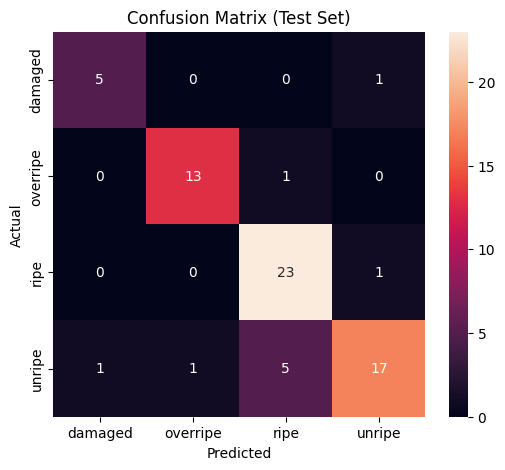

In [ ]:
y_true = []
y_pred = []

for class_index, class_name in enumerate(class_names):
    class_folder = os.path.join(test_path, class_name)

    for img_name in os.listdir(class_folder):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):

            img_path = os.path.join(class_folder, img_name)

            result = model.predict(img_path, verbose=False)
            pred_class = result[0].probs.top1

            y_true.append(class_index)
            y_pred.append(pred_class)

# ----------------------------------
# Classification Report
# ----------------------------------
print("\n📋 Classification Report (Per Class)")
print(classification_report(y_true, y_pred, target_names=class_names))

# ----------------------------------
# Confusion Matrix
# ----------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.show()

Per-Class **Accuracy**

In [ ]:
import os
import numpy as np
from collections import defaultdict

correct_per_class = defaultdict(int)
total_per_class = defaultdict(int)

for class_index, class_name in enumerate(class_names):
    class_folder = os.path.join(test_path, class_name)

    for img_name in os.listdir(class_folder):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):

            img_path = os.path.join(class_folder, img_name)
            result = model.predict(img_path, verbose=False)
            pred_class = result[0].probs.top1

            total_per_class[class_name] += 1
            if pred_class == class_index:
                correct_per_class[class_name] += 1

print("\n📊 Per-Class Accuracy")
for cls in class_names:
    acc = correct_per_class[cls] / total_per_class[cls]
    print(f"{cls}: {acc:.4f}")


📊 Per-Class Accuracy
damaged: 0.8333
overripe: 0.9286
ripe: 0.9583
unripe: 0.7083


# 📊 Palm Fruit Classification – Test Results (4 Classes)

## 🔹 Overall Test Metrics

- **Top-1 Accuracy:** 95.61%
- **Top-5 Accuracy:** 100%

> Note: Since this is a 4-class problem, Top-5 accuracy is not very meaningful.

---

## 📋 Classification Report (Per Class)

| Class     | Precision | Recall | F1-Score | Support |
|-----------|----------|--------|----------|----------|
| Damaged   | 0.83     | 0.83   | 0.83     | 6        |
| Overripe  | 0.93     | 0.93   | 0.93     | 14       |
| Ripe      | 0.79     | 0.96   | 0.87     | 24       |
| Unripe    | 0.89     | 0.71   | 0.79     | 24       |
| **Macro Avg** | 0.86 | 0.86 | 0.86 | 68 |
| **Weighted Avg** | 0.86 | 0.85 | 0.85 | 68 |

---

## 📊 Per-Class Accuracy

| Class     | Accuracy |
|-----------|----------|
| Damaged   | 83.33%   |
| Overripe  | 92.86%   |
| Ripe      | 95.83%   |
| Unripe    | 70.83%   |

---

## 🔍 Interpretation

- The model performs **very well overall**, achieving high Top-1 accuracy.
- **Ripe** and **Overripe** classes show strong classification performance.
- **Damaged** class performs reasonably well despite limited samples.
- **Unripe** class has lower recall, indicating some misclassification.
- Class imbalance (only 6 damaged samples) may affect stability.

---


**Show Misclassified Images (Error Analysis)**


❌ Misclassified Samples


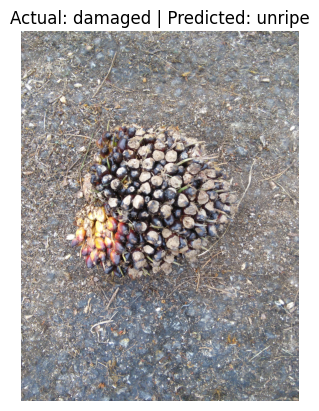

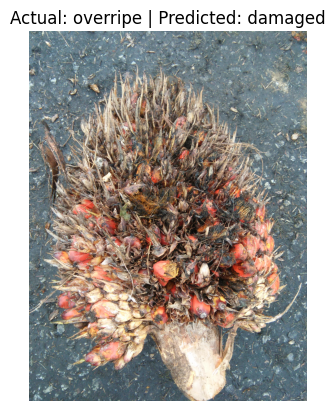

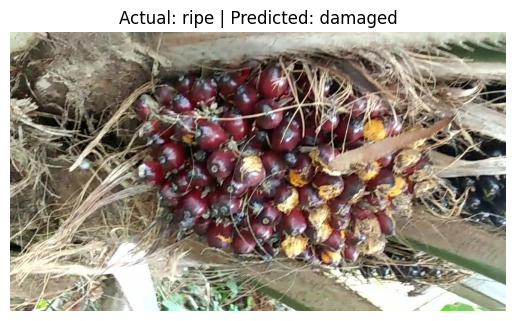

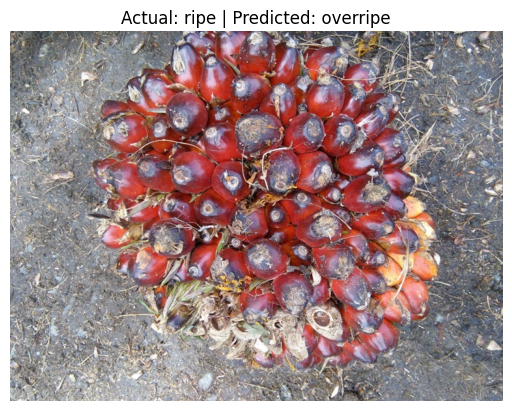

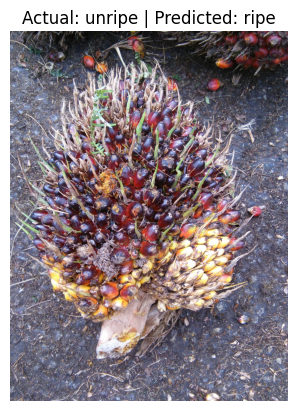

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

print("\n❌ Misclassified Samples")

count = 0
for class_index, class_name in enumerate(class_names):
    class_folder = os.path.join(test_path, class_name)

    for img_name in os.listdir(class_folder):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):

            img_path = os.path.join(class_folder, img_name)
            result = model.predict(img_path, verbose=False)
            pred_class = result[0].probs.top1

            if pred_class != class_index:
                img = Image.open(img_path)
                plt.imshow(img)
                plt.title(f"Actual: {class_name} | Predicted: {class_names[pred_class]}")
                plt.axis('off')
                plt.show()

                count += 1
                if count == 5:   # show only 5 mistakes
                    break
    if count == 5:
        break

**Inference Speed Test**

In [ ]:
import time
import random

# pick random image
sample_class = random.choice(class_names)
sample_folder = os.path.join(test_path, sample_class)
sample_image = random.choice(os.listdir(sample_folder))
sample_path = os.path.join(sample_folder, sample_image)

start = time.time()
model.predict(sample_path, verbose=False)
end = time.time()

print("\n⏱ Inference Time:", round((end - start)*1000, 2), "ms")


⏱ Inference Time: 17.61 ms


**Compare Train vs Validation Loss (Overfitting Check)**

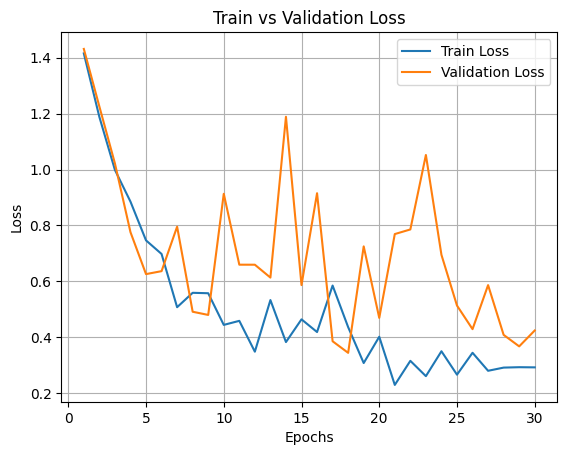

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_path = "/content/runs/classify/train/results.csv"
results = pd.read_csv(results_path)

plt.figure()
plt.plot(results['epoch'], results['train/loss'], label='Train Loss')
plt.plot(results['epoch'], results['val/loss'], label='Validation Loss')
plt.legend()
plt.title("Train vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()